# MonOCR Preview
Simple demonstration of Mon Language OCR on Images and PDFs.

In [1]:
import io
import os
import torch
from pathlib import Path
from PIL import Image

from pdf2image import convert_from_path
from IPython.display import display, Image as IPyImage, Markdown

from monocr import MonOCR

In [2]:
project_root = Path("..")
img_dir = project_root / "data" / "images"
pdf_dir = project_root / "data" / "pdfs"

In [3]:
try:
    ocr = MonOCR()
    print("Ready")
except Exception as e:
    print(f"Init failed: {e}")

Ready


In [4]:
def display_pil_image(img: Image.Image):
    buf = io.BytesIO()
    img.save(buf, format="PNG")
    display(IPyImage(data=buf.getvalue()))

## Image OCR
Processing all images in `data/images`.

Found 7 images



## 000028.jpg

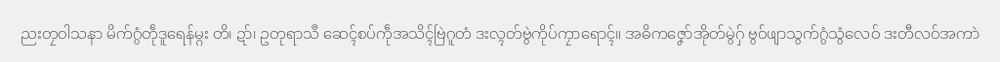

**OCR Result:**

```
ညးတၠဝါသနာမိက်ဂွံတဵုဒူရေန်မ္ဂးတိ၊ဍာ်၊ဥတုရာသဳဆေၚ်စပ်ကဵုအသိၚ်ဗြဲဂူတံဒးလ္ၚတ်ဗွဲကိုပ်ကၠာရောၚ်။အဓိကဇၞော်အိုတ်မွဲဂှ်ဗွဝ်ဖျာသွက်ဂွံသွံလေဝ်ဒးတီလဝ်အကာဲ
```

------------------------------------------------------------


## 000029.jpg

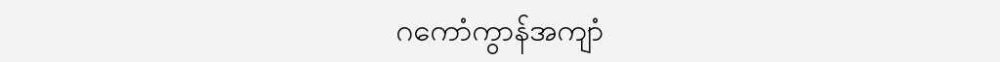

**OCR Result:**

```
ဂကောံကွာန်အကျာံ
```

------------------------------------------------------------


## pdf_screenshot.png

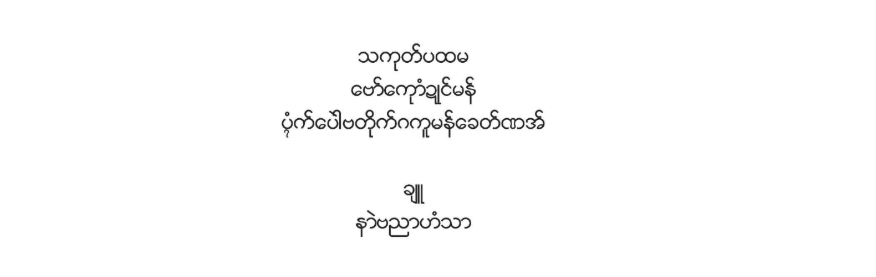

**OCR Result:**

```
သကုတ်ပထမ
ဗော်ကေုာံဍုင်မန်
ပ္ၚံက်ပေါဲဗတိုက်ဂကူမန်ခေတ်ဏအ်
ချဵု
နာဲဗညာဟံသာ
```

------------------------------------------------------------


## test_0005_h71.png

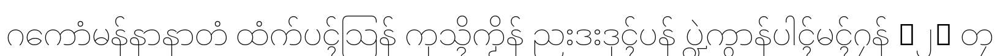

**OCR Result:**

```
ဂကောံမန်နာနာတံထံက်ပၚ်သြန်ကုသ္ၚိကၟိန်ညးဒးဒုၚ်ပန်ပ္ဍဲကွာန်ပါၚ်မၚ်ဂၠန်(၂)တၠ
```

------------------------------------------------------------


## test_0006_h61.png

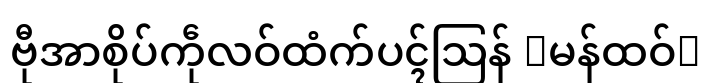

**OCR Result:**

```
ဗီုအာစိုပ်ကဵုလဝ်ထံက်ပၚ်သြန်(မန်ထဝ်)
```

------------------------------------------------------------


## test_0011_h30.png

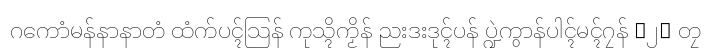

**OCR Result:**

```
ဂကောံမန်နာနာတံထံက်ပၚ်သြန်ကုသ္ၚိကၟိန်ညးဒးဒုၚ်ပန်ပ္ဍဲကွာန်ပါၚ်မၚ်ဂၠန်(၂)တၠ
```

------------------------------------------------------------


## test_0012_h86.png

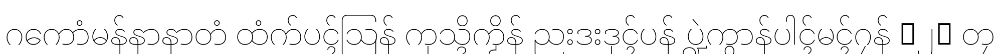

**OCR Result:**

```
ဂ)ကောံမန်နာနာတံထံက်ပၚ်သြန်ကုသ္ၚိကၟိန်ညးဒးဒုၚ်ပန်ပ္ဍဲကွာန်ပါၚ်မၚ်ဂၠန်(၂))တ်။
```

------------------------------------------------------------


In [5]:
if not img_dir.exists():
    print("No image folder")
else:
    images = sorted(
        list(img_dir.glob("*.png")) +
        list(img_dir.glob("*.jpg")) +
        list(img_dir.glob("*.jpeg"))
    )

    print(f"Found {len(images)} images\n")

    for img_path in images:
        display(Markdown(f"## {img_path.name}"))

        # Run OCR
        text = ocr.read_text(img_path)

        # Show image
        display(IPyImage(filename=str(img_path)))

        # Show result
        display(Markdown("**OCR Result:**"))
        display(Markdown(f"```\n{text}\n```"))

        print("-" * 60)

## PDF OCR
Processing all PDFs in `data/pdfs`.

Found 1 PDFs



# party_mission.pdf

## Page 1

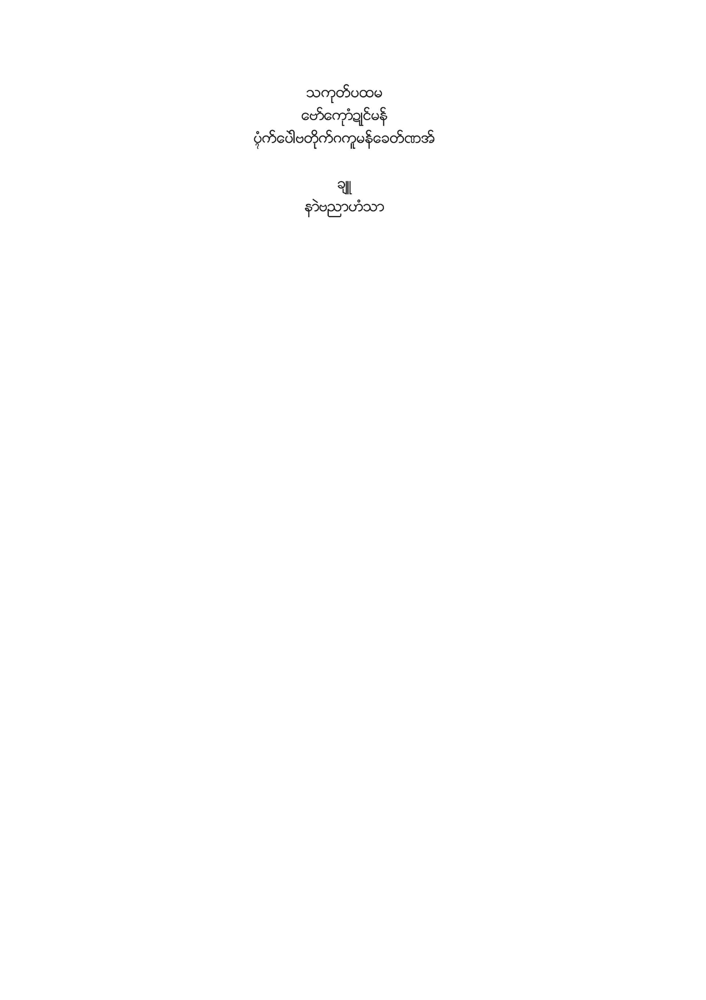

**OCR Result:**

```
သကုတ်ပထမ
ဗော်ကေုာံဍုင်မန်
ပ္ၚံက်ပေါဲဗတိုက်ဂကူမန်ခေတ်ဏအ်
ပျု{
နာဲဗညာဟံသာ
```

----------------------------------------


## Page 2

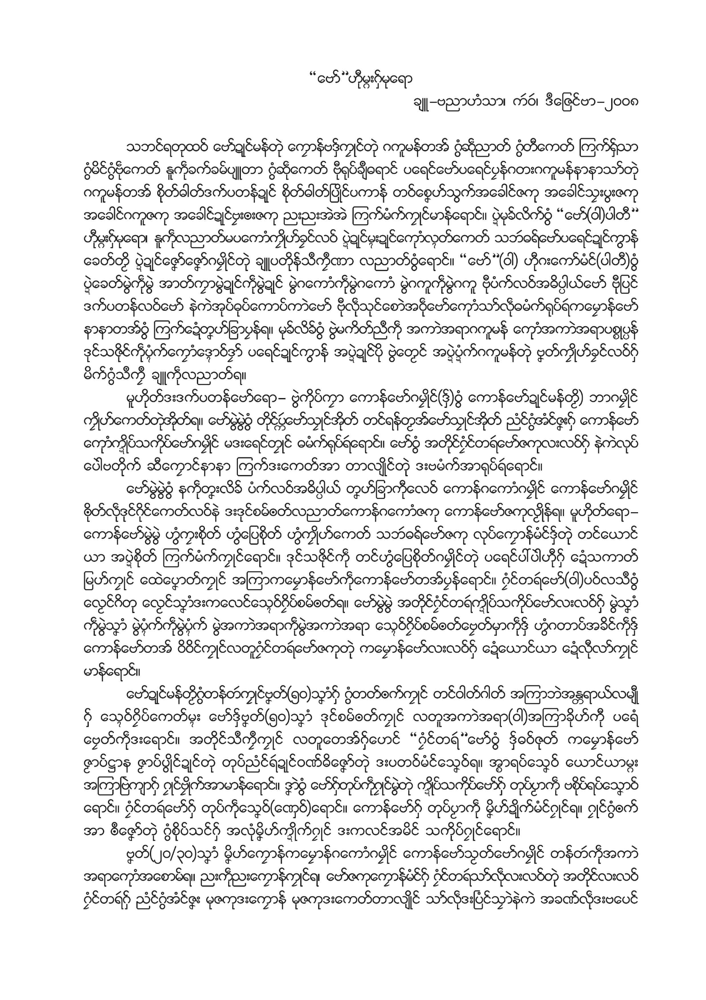

**OCR Result:**

```
င်ဗော်’"ဟီုမ္ဂးဂှ်မုရော
ချူ-ဗညာဟံသာ၊ကဴဝဴ၊ဒဳဇြေၚ်ဗာ-၂၀၀၈
သဘင်ရတုထဝ်ဗော်ဍုင်မန်တုဲကၠောန်ဗဒှ်ကၠုင်တုဲဂကူမန်တအ်ဂွံဆ်ုညာတ်ဂွံတီကေတ်ကြက်ရှ်ာာ
ဂွံမိၚ်ဂွံဗဵုကေတ်နူကဵုခက်ခမ်ပျူတာဂွံဆဵုကေတ်ဗီုရုပ်ချဳဓရာၚ်ပရေၚ်ဗော်ပရေၚ်ပၠန်ဂတးဂကူမန်နာနာသာ်တုဲ
ဂကူမန်တအ်စိုတ်ဓါတ်ဒက်ပတန်ဍုင်စိုတ်ဓါတ်ပြိုၚ်ပကာန်တဝ်စၞေဟ်သွက်အခေါၚ်ဇကုအခေါၚ်သၠးပွးဇကု
အခေါၚ်ဂကူဇကုခေါင်ဍုင်ဗၠးစးဇကုညးညးအဲအဲကြက်မံက်ကၠုၚ်မာန်ရောၚ်။ပ္ဍဲမုခ်လိက်ဝွံ‘ဗော်ဝါဲ)ပါတီ(
ဟီုမ္ဂးဂှ်မုရောါနူကဵုလညာတ်မပကောံကၠိုဟ်ခၠင်လဝ်ပ္ဍဲဍုၚ်မ္ၚးဍုင်ကေုာံံလ္ၚတ်ကေတ်သဘဴဓရ်ဗော်ပရေင်ဍုင်ကွာန်
ခေတ်တၟိပ္ဍဲဍုၚ်ဇၞော်ဇၞော်ဂမၠိုၚ်တုဲချူပတိုန်သဳကၠဳဏာလညာတ်ဝွံရောၚ်။*ဗော်((ဝါဲ)ဟီုဂးကော်မံၚ်(ပါတီ)ဝွံ
ပ္ဍဲခေတ်မွဲကဵုမွဲအာတ်ကၠာမွဲဍုင်ကဵုမွဲဍုင်မွဲဂကောံကဵုမွဲဂကောံမွဲဂကူကဵုမွဲဂကူဗီုပံက်လဝ်အမိပ္ပါယ်ဗော်ဗီုပြၚ်
ဒက်ပတန်လဝ်ဗော်နဲကဲအုပ်ဓုပ်ကောပ်ကာဲဗော်ဗီုလဵုသုၚ်စောဲအဝ်ဵုဗော်ကေုာံသာ်လဵုဓမံက်ရုပ်ရဴကမၠောန်ဗော်
နာ)န?တအ်ဝွံကြက်ဍေံတၞဟ်ခြာပၠန်ရ။မုခ်လိခ်ဝွံဗွဲမကိတ်ညဳကဵုကာဲအရာဂကူမန်ကေုာံအကာဲအရာပစွိုပ္ပန်
ဒုၚ်သဇိုၚ်ကဵုပ္ၚံက်ကၠောံဒ္ၚောပ်ဒၠာ်ပရေင်ဍုင်ကွာန်အပ္ဍဲဍုင်ပိုဲဗွဲတၟေၚ်အပ္ဍဲပ္ဍံက်ဂကူမန်တုဲဗၞတ်ကၠိုဟ်ခၠၚ်လဝ်ဂှ်
မိက်ဂွံသီကၠဳချူကဵုလညာတ်ရ။
မူဟိုတ်ဒးဒက်ပတန်ဗော်ရော-ဗွဲကိုပ်ကၠာကောန်ဗော်ဂမၠိုၚ်(ဒှ်)ဝွံကောန်ဗော်ဍုၚ်မန်တၟိ)ဘာဂမၠိုၚ်
ကၠိုဟ်ကေတ်တုဲအိုတ်ရ။ဗော်မွဲမွဲဝွံတိုၚ်ပ္ကဴဗော်သသၠုၚ်အိုတ်တဝ်ရန်တၟအ်ဗော်သၠုၚ်အိုတ်ညံၚ်ဂွံအံင်ဇၞးဂှ်ကောန်ဗော်
ကေုာံက္ဍိုပ်သကိုပ်ဗော်ဂမၠိုၚ်မဒးရေင်တၠုင်ဓမံက်ရုပ်ရဴရောၚ်ူဗော်ဝွံအတိုင်ဂၠံၚ်တရဴဗော်ဇကုလးလဝ်ဂှ်နဲကဲလုပ်
ပေဲဗတိုက်ဆီကၠောၚ်နာနာကြက်ဒးကေတ်အာတာလျိုၚ်တုဲဒးဗမံက်အာရုပ်ရဴရောၚ်။
ဗော်မွဲမွဲဝွံနကဵုတၞးလိခ်ပံက်လဝ်အဓိပ္ပါယ်တၞဟ်ခြာကီုလေဝ်ကောန်ဂကောံဂမၠိုၚ်ကောန်ဗော်ဂမၠိုၚ်
ၜိုတ်လဵုဒုၚ်ဂိုၚ်ကေတ်လဝ်နဲဒးဒုၚ်စမ်စတ်လညာတ်ကောန်ဂကောံဇကုကောန်ဗော်ဇကုလၟိုန်ရ။မူဟိုတ်ရော-
ကောန်ဗော်မွဲမွဲဟွံကၠးစိုတ်ဟွံပြေစိုတ်ဟွံကၠိုဟ်ကေတ်သဘဴဓရ်ဗော်ဇကုလုပ်ကၠောန်မံၚ်ဒှ်တုဲတၚ်ယောၚ်
ယာအပ္ဍဲစိုတ်ကြက်မံက်ကၠုၚ်ရောၚ်။ဒုၚ်သဇိုၚ်ကဵုတၚ်ဟွံပြေစိုတ်ဂမၠိုၚ်တုဲပရေၚ်ပါဲပဲါဲဟီုဂှ်ဍေံသကာတ်
မြဟ်ကၠုၚ်ထေဲပၞောတ်ကၠုၚ်အကြာကမၠောန်ဗော်ကဵုကောန်ဗော်တအ်ပၠန်ရောၚ်။ဂၠံၚ်တရဴဗော်(ဝါဲ)ပဝ်လသီဝွံ
လၟေၚ်ဂိတုလၟေၚ်သၞာံဒးကလေၚ်သ္ၚေဝ်ဂၠိပ်စမ်စတ်ရ။ဗော်မွဲမွဲအတိုၚ်ဂၠံၚ်တရဴက္ဍိုပ်သကိုပ်ဗော်လးလဝ်ဂှ်မွဲသၞာံ
ကဵုမွဲသၞာံမွဲပ္ၚံက်ကဵုမွဲပ္ၚံက်မွဲအကာဲအရာကဵုမွဲအကာဲအရာသ္ၚေဝ်ဂၠိပ်စမ်စတ်ဗၠေတ်မှာကဵုဒှ်ဟွံဂတာပ်အခိၚ်ကဵုဒှ်
ကောန်ဗော်တအ်ဝိဝိၚ်ကၠုၚ်လတူဂၠံၚ်တရဴဗော်ဇကုတုဲကမၠောန်ဗော်လးလဝ်ဂှ်ဍေံယောၚ်ယာဍေံလီုလာ်ကၠုၚ်
ဝ်)ာ်၆၆ါ်)်l|
ဗော်ဍုၚ်မန်တၟိဂွံတန်တဴကၠုၚ်ဗၞတ်၅၀)သၞာံဂှ်ဂွံတတ်စက်ကၠုင်တင်ဝါတ်ဂါတ်အကြာဘဲအန္တရာယ်လမျီု
ဂှ်သ္ၚေဝ်ဂၠိပ်ကေတ်မ္ၚးဗော်ဒှ်ဗၞတ်(၅၀)သၞာံဒုၚ်စမ်စတ်ကၠုင်လတူအကာဲအရာ(ဝါဲ)အကြာခိုဟ်ကီုပရေံ
ဗၠေတ်ကဵုဒးရောၚ်။အတိုင်သီကၠဳကၠုင်လတူတေအ်ဂှ်ဟေၚ်ှဂၠံၚ်တရဴ"ဗော်ဝွံဒှ်ဓဝ်ဇုတ်ကမၠောန်ဗော်
ဇၟာပ်ဋ္ဌာနဇၟာပ်ပွိုၚ်ဍုၚ်တုဲတုပ်ညံၚ်ရဴဍုင်ဝဏ်မိဇၞော်တုဲဒးပတဝ်မံၚ်သၞေဝ်ရ။အ္စာရပ်သၞေဝ်ယောၚ်ယာမ္ဂး
အကြာဗြကျာဂှ်ဂၠုၚ်ဗၠိုက်အအ်မာန်ရောဝ်။ဒၞာဲဝွံဗော်ဂှ်တုပ်က်္ဂၠု်မွဲဲတုဲက္ဍိုပ်သကိုပ်ဗော်ဂှ်တုပ်ပၟာကဵုဗစိုပ်ရပ်သၞောဝ်
ရောၚ်။ဂၠံၚ်တရဴဗော်ဂှ်တုပ်ကဵုသၞေဝ်(ဏှေဝ်)ရောၚ်။ကောန်ဗော်ဂှ်တုပ်ပၟာကဵုမၞိဟ်ဍိုက်မံၚ်ဂၠုၚ်ရ။ဂၠုၚ်ဂွံစက်
အာၜဳဇၞော်တုဲဂွံစိုပ်သၚ်ဂှ်အလုံမၞိဟ်က္ဍိုက်ဂၠုၚ်ဒးကလၚ်အမိၚ်သကိုပ်ဂၠုၚ်ရောၚ်။
ဗၞတ်(၂၀/၃၀)သၞာံမၞိဟ်ကၠောန်ကမၠောန်ဂကောံဂမၠိုၚ်ကောန်ဗော်သၟတ်ဗော်ဂမၠိုၚ်တန်တဴကဵုအကာဲ
အခရာကေုာံအအစောမ်ရ။ညးက်္ုညးကၠောန်ကၠုၚ်ရဗော်ဇကုကၠောန်မံၚ်ဂှ်ဂၠံပ်တရဴာ်ၚ်ုလးလဝ်တုဲအတိုပ်လးလဝ်
ဂၠံၚ်တရဴဂှ်ညံၚ်ဂွံအံၚ်ဇၞးမုဇကုဒးကၠောန်မုဇကုဒးကေတ်တာလျိုၚ်သာ်လဵုဒးပြံၚ်သၠာဲနဲကဲအခဏ်လဵုဒးဗပေၚ်
```

----------------------------------------


## Page 3

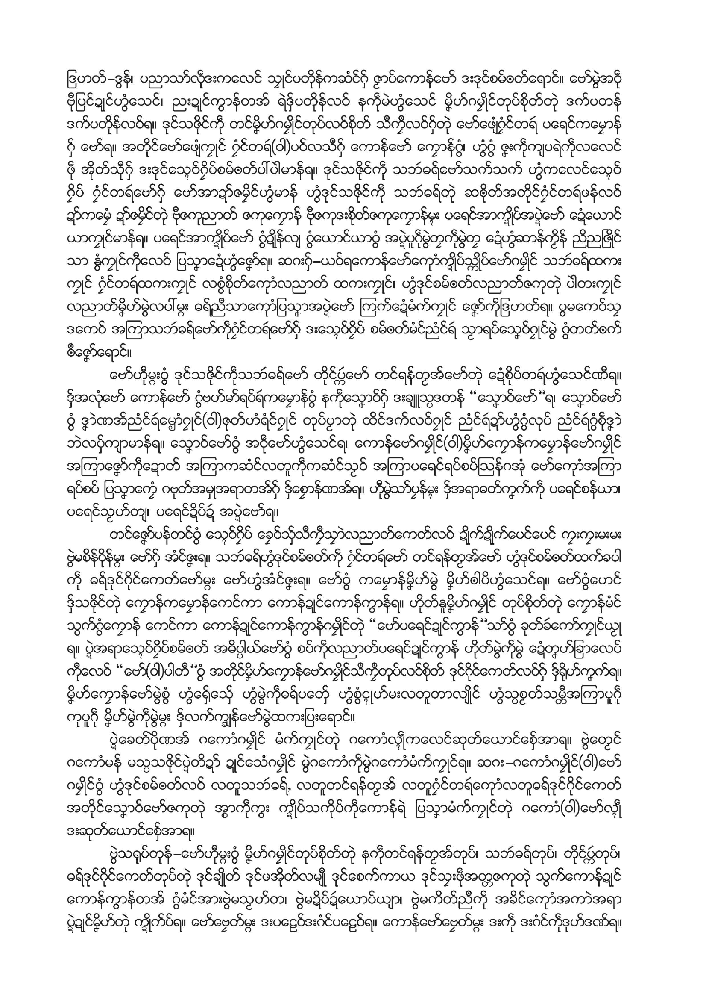

**OCR Result:**

```
ဒြဟတ်-ွန်၊ပညာသာ်လဵုဒးကလေၚ်သၠုင်ပတိုန်ကဆံင်ဂှ်ဇၟာပ်ကောန်ဗော်ဒးဒုင်စမ်စတ်ရောၚ်။ဗော်မွဲအအဝ်ု
ဗီုပြၚ်ဍုၚ်ဟွံသေၚ်၊ညးဍုင်ကွာန်တအ်ရဲဒှ်ပတိုန်လဝ်နကဵုမဲဟွံသေၚ်မၞိဟ်ဂမၠိုၚ်တုပ်စိုတ်တုဲဒက်ပတန်
ဒက်ပတိုန်လဝ်ရ။ဒုၚ်သဇိုၚ်ကဵုတၚ်မၞိဟ်ဂမၠိုၚ်တုပ်လဝ်စိုတ်သဳကၠဳလဝ်ဂှ်တုဲဗော်ဖျေံဂၠံၚ်တရဴပရေၚ်ကမၠောန်
ဂှ်ဗော်ရ။တိုၚ်ဗော်ဖျေံကၠုၚ်ဂၠံၚ်တရဴ(ဝါဲ)ပဝ်လသဳဂှ်ကောန်ဗော်ကၠောန်ဂွံဟွံဂွံဇၞးကဵုကျပရဲကဵုလလေၚ်
ဖဵုအိုတ်သီုဂှ်ဒးဒုၚ်သ္ၚေဝ်ဂၠိပ်စမ်စတ်ပါဲပါဲမာန်ရ။ဒုၚ်သဇိုၚ်ကဵုသဘဴဓရ်ဗော်သက်သက်ဟွံကလေၚ်သ္ၚေဝ်
ဂၠိပ်ဂၠံၚ်တရဴဗော်ဂှ်ဗော်အာဍာ်ဇမၠိၚ်ဟွံမာန်ဟွံဒုၚ်သဇိုၚ်ကဵုသဘဴဓရ်တုဲဆၜိုတ်အတိုၚ်ဂၠံၚ်တရဴဖန်လဝ်
ဍာ်ကမၠေံဍာ်းမၠိ်တုဲဗီုဇကုညာတ်ဇကုကၠောန်ဗီုဇကုဒးစိုတ်ဇကုကၠောန်မ္ၚးပရေၚ်အ်က္ဍိုပ်အပ္ဍဲဗော်ဍေံယောၚ်
ယာကၠုၚ်မာန်ရ။ပရေၚ်အာက္ဍိုပ်ဗော်ဂွံဍိုန်လျဂွံယောၚ်ယာဝွံအပ္ဍဲပူဂ်ုမွဲတၠက်ဵုမွဲတၠဍေံဟွံဆာန်ကၟိန်ညိညဇြိုၚ်
သာနွံကၠုၚ်ကီုလေဝ်ပြသၞာဍေံဟွံဇၞော်ရ။ဆဂးဂှ်-ယဝ်ရကောန်ဗော်ကေုာံက္ဍိုပ်သ္ကိုပ်ဗော်ဂမၠိုၚ်သဘဴဓရ်ထကး
ကၠုၚ်ဂၠံၚ်တရဴထကးကၠုၚ်လစွံစိုတ်ကေုာံလညာတ်ထကးကၠုၚ်၊ဟွံဒုၚ်စမ်စတ်လညာတ်ဇကုတုဲပါဲတးကၠုၚ်
လညာတ်မၞိဟ်မွဲလပါဲမ္ဂးဓရ်ညဳသာကေုာံပြသၞာအပ္ဍဲဗော်ကြက်ဍေံမံက်ကၠုၚ်ဇၞော်ကဵုဒြဟတ်ရ။ပွမကေဝ်သၠ
ဒကေဝ်အကြာသဘဴဓရ်ဗော်က်ုဂၠံၚ်တရဴဗော်ဂှ်ဒးသ္ၚေဝ်ဂၠိပ်စမ်စတ်မံၚ်ညံၚ်ရဴသၟာရပ်သၞေဝ်ဂၠုၚ်မွဲဂွံတတ်စက်
ၜဳဇၞော်ရောၚ်ူ
ဗော်ဟီုမ္ဂးဝွံဒုၚ်သဇိုၚ်ကဵုသဘဴဓရ်ဗော်တိုၚ်ပ္ကဴဗော်တၚ်ရန်တၟအ်ဗော်တုဲဍေံစိုပ်တရဴဟွံသေၚ်ဏီရ။
ဒဒှ်အလုံဗော်ကောန်ဗော်ဂွံဗဟ်မာ်ရပ်ရဴကမၠောန်ဝွံနကဵုသၞောဝ်ဂှ်ဒးချူသ္ပဒတန်"သၞောဝ်ဗော်’ရ၊သၞောဝ်ဗော်
ဝွံဒၞာဲဏအ်ညံၚ်ရဴၝောံဂၠုၚ်(ဝါဲ)ဇုတ်ဟံရံၚ်ဂၠုၚ်တုပ်ပၟာတုဲထိၚ်ဒက်လဝ်ဂၠုၚ်ညံၚ်ရဴဍာ်ဟွံဂွံလုပ်ညံၚ်ရဴဂွံစဵုဒၞာဲ
ဘဲလပှ်ကျာမာန်ရ။သၞောဝ်ဗော်ဝွံအအဝဵုဗော်ဟွံသေၚ်ရ၊ကောန်ဗော်ဂမၠိုၚ်(ဝါဲ)မၞိဟ်ကၠောန်ကမၠောန်ဗော်ဂမၠိုၚ်
အကြာဇၞော်ကဵုဍောတ်အအကြာကဆံင်လတူကဵုကဆံင်သၟဝ်အကြာပရေၚ်ရပ်စပ်သြန်ဂအုံဗော်ကေုာံအကြာ
ရပ်စပ်ပြသၞာကၠေံဂဗုတ်အအမှအရာတအ်ဂှ်ဒှ်စၠောန်ဏအ်ရ။ဟီုမွဲသာ်ပၠန်မ္ၚးဒှ်အရာမတ်ကၞက်ကဵုပရေၚ်စန်ယာ
ပရေၚ်သၟဟ်တျ၊ပရေၚ်ဍိပ်ဍဴအပ္ဍဲဗော်ရ၊၊
တၚ်ဇၞော်ပန်တၚ်ဝွံသ္ၚေဝ်ဂၠိပ်ခၠေဝ်သှ်သဳကၠဳသၠာဲလညာတ်ကေတ်လဝ်ဍိုက်ဍိုက်ပေၚ်ပေၚ်ကၠးကၠးမးမး
ဗွဲမစိန်ဝိုန်မ္ဂးဗော်ဂှ်အံၚ်ဇၞးရ။သဘဴဓရ်ဟွံဒုင်စမ်စတ်ကဵုဂၠံၚ်တရဴဗော်တင်ရန်တၟအ်ဗော်ဟွံဒုၚ်စမ်စတ်ထက်ခပါဲ
ကဵုဓရ်ဒုၚ်ဂိုၚ်ကေတ်ဗော်မ္ဂးဗော်ဟွံအံၚ်ဇၞးရ။ဗော်ဝွံကမၠောန်မၞိဟ်မွဲမၞိဟ်ၜါပိဟွံသေၚ်ရ။ဗော်ဝွံဟေၚ်
ဒဒှ်သဇိုၚ်တုဲကၠောန်ကမၠောန်ကေၚ်ကာကောန်ဍုင်ကောန်ကွာန်ရ။ဟိုတ်နူမၞိဟ်ဂမၠိုၚ်တုပ်စိုတ်တုဲကၠောန်မံၚ်
သွက်ဂွံကၠောန်ကေၚ်ကာကောန်ဍုင်ကောန်ကွာန်ဂမၠိုၚ်တုဲ*ဗော်ပရေၚ်ဍုင်ကွာန်သာ်ဝွံခုတ်ခဴကော်ကၠုၚ်ယၟု
ရ။ပ္ဍဲအရာသ္ၚေဝ်ဂၠိပ်စမ်စတ်ဓိပ္ပါယ်ဗော်ဝွံစပ်ကဵုလညာတ်ပရေၚ်ဍုၚ်ကွာန်ဟိုတ်မွဲကဵုမွဲဍေံတၞဟ်ခြာလေပ်
ကီုလေဝ်*ဗော်(ဝါဲဲပါတီ’ဝွံတိုၚ်မၞိဟ်ကၠောန်ဗော်ဂမၠိုၚ်သဳကၠဳတုပ်လလဝ်စိုတ်ဒုၚ်ဂိုင်ကေတ်လလဝ်ဂှ်ဒှ်ရိုဟ်ကၞက်ရ။
မၞိဟ်ကၠောန်ဗော်မွဲစွံဟွံရှ်ေသှ်ေဟွံမွဲကဵုဓရ်ပတှ်ေဟွံစွံၚုဟ်မးလတူတာလျိုင်ဟွံသ္ပစၟတ်သမ္တီအကြာပူဂဵု
ကုပူဂဵုမၞိဟ်မွဲကဵုမွဲမ္ဂးဒှ်လက်က္ျန်ဗော်မွဲထကးပြးရောၚ်။
ပ္ဍဲခေတ်ပိုဲဏအ်ဂကောံဂမၠိုၚ်မံက်ကၠုၚ်တုဲဂကောံလ္ၚဵုကလေၚ်ဆုတ်ယောၚ်စှ်ေအာရ။ဗွဲတၟေၚ်
ဂကောံမန်မသ္ပသဇိုၚ်ပ္ဍဲတိဍာ်ဍုၚ်သေံဂမၠိုၚ်မွဲဂကောံကဵုမွဲဂကောံမံက်ကၠုၚ်ရ။ဆဂး-ဂကောံဂမၠိုၚ်(ဝါဲ)ဗော်
ဂမၠိုၚ်ဝွံဟွံဒုၚ်စမ်စတ်လဝ်လတူသဘဴဓရ်,လတူတၚ်ရန်တၟအ်လတူဂၠံၚ်တရဴကေုာံလတူဓရ်ဒုၚ်ဂိုၚ်ကေတ်
အတိုၚ်သၞောဝ်ဗော်ဇကုတုဲအ္စာကဵုကွးက္ဍိုပ်သကိုပ်ကဵုကောန်ရဲပြသၞာမံက်ကၠုၚ်တုဲဂကောံ(ဝါဲ)ဗော်လ္ၚဵု
၀ိ၀))၆D)ပ်၆၀)0)၆ါ||
ဗွဲသရုပ်တုန်-ဗော်ဟီုမ္ဂးဝွံမၞိဟ်ဂမၠိုၚ်တုပ်စိုတ်တုဲနကဵုတၚ်ရန်တၟအ်တုပ်ါ၊သဘဴဓရ်တုပ်၊တိုၚ်ပ္ကဴတုပ်ါ၊
ဓရ်ဒုင်ဂိုင်ကေတ်တုပ်တုဲဒုင်ချိုတ်ဒုၚ်ဖအိုတ်လမျီုဒုၚ်စေက်ကာယဒုၚ်သၠးဖဵုအတ္တဇကုတုဲသွက်ကောန်ဍုၚ်
ကောန်ကွာန်တအ်ဂွံမံၚ်အားဗွဲမသၟဟ်တါဗွဲမဍိပ်ဍဴယောပ်ယျာါဗွဲမကိတ်ညဳကဵုအအခိၚ်ကေုာံအကာဲအရာ
ပ္ဍဲဍုၚ်မၞိဟ်တုဲက္ဍိုက်ပ်ရ။ဗော်ဗၠေတ်မ္ဂးဒးပဠေဝ်ဒးဂံၚ်ပဠေဝ်ရ။ကောန်ဗော်ဗၠေတ်မ္ဂးဒးကဵုဒးဂံင်ကဵုဒုဟ်ဒဏ်ရ။
```

----------------------------------------


## Page 4

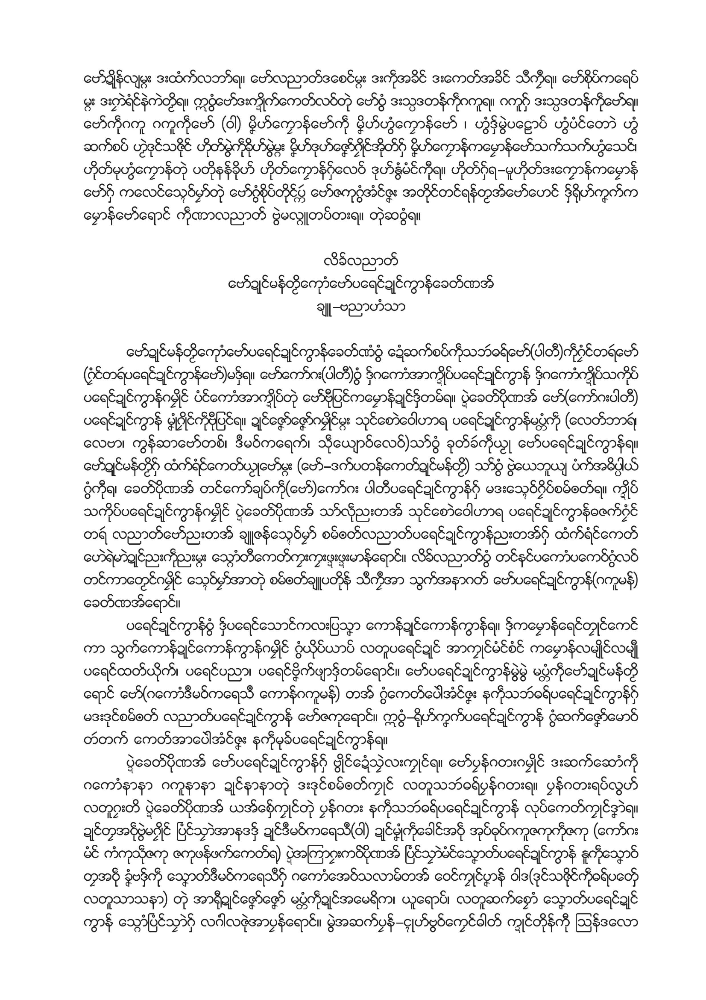

**OCR Result:**

```
ဗော်ဍိုန်လျမ္ဂးဒးထံက်လလဘာ်ရ။ဗော်လလညာတ်ဒစေင်မ္ဂးဒးကဵုအခိင်ဒးကေတ်အခိင်သဳကၠဳရ။ဗော်စိုပ်ကရေပ်
မ္ဂးဒးဂၠာဲရံၚ်နဲကဲတၟိရ။ဣဝွံဗော်ဒးက္ဍိုက်ကေတ်လလဝ်တုဲဗော်ဝွံဒးသ္ပဒတန်ကဵုဂကူရ။ဂကူဂှ်ဒးသ္ပဒတန်ကဵုဗော်ရ။
ဗော်ကဵုဂကူဂကူကဵုဗော်(ဝါဲ)မၞိဟ်ကၠောန်ဗော်ကဵုမၞိဟ်ဟွံကၠောန်ဗော်၊ဟွံဒှ်မွဲပဠောပ်ဟွံပံၚ်တောဲဟွံ
ဆာက်စပ်ဟၟဲဒုၚ်သဇိုၚ်ဟိုိတ်မွဲက်ဵုခိုဟ်မွဲမ္ဂးမၞိဟ်ဒုဟ်ဇၞော်ဂၠိုၚ်အိုတ်ဂှ်မၞိဟ်ကၠောန်ကမၠောန်ဗော်ဿက်က်ဟွံသေဝ်
ဟိုတ်မုဟွံကၠောန်တုဲပတိုနန်ခိုဟ်ဟိုတ်ကၠောန်ဂှ်လေဝ်ဒုဟ်ဝွံမံၚ်ကီုရ။ဟိုတ်ဂှ်ရ-မူဟိုတ်ဒးကၠောန်ကမၠောန်
ဗော်ဂှ်ကလေၚ်သ္ၚေဝ်မၠာ်တုဲဗော်ဂွံစိုပ်တိုၚ်ပ္ကဴဗော်ဇကုဂွံအံၚ်ဇၞးအတိုင်တင်ရန်တၟအ်ဗော်ဟေၚ်ဒှ်ရိုဟ်ကၞက်က
မၠောန်ဗော်ရောၚ်ကဵုဏာလညာတ်ဗွဲမလ္ဂူတပ်တးရ။တုဲဆဝွံရ။
လိခ်လညာတ်
ဗော်ဍုင်မန်တၟိကေုာံဗော်ပရေင်ဍုင်ကွာန်ခေတ်ဏအ်
ပျ{ဗ်ပ််
ဗော်ဍုင်မန်တၟိကေုာံဗော်ပရေၚ်ဍုင်ကွာန်ခေတ်ဏံဝွံဍေံဆက်စပ်ကဵုသဘဴဓရ်ဗော်(ပါတီ)ကဵုဂၠံၚ်တရဴဗော်
ဂၠံၚ်တရဴပရေၚ်ဍုၚ်ကွာန်ဗော်ါမဒှ်ရ။ဗော်ကော်ဂးပါဲတီဝွံဒှ်ဂကောံအက္ဍိုပ်ပရေၚ်ဍုၚ်ကွာန်ဒှ်ဂကောံက္ဍိုပ်သကိုပ်
ပရေၚ်ဍုင်ကွာန်ဂမၠိုၚ်ပံင်ကောံ်က္ဍိုပ်တုဲဗော်ဗီုပြၚ်ကမၠောန်ဍုင်ဒှ်တမ်ရ။ပ္ဍဲခေတ်ပိုဲဏအ်ဗော်(ကော်ဂးပါတီ)
ပရေၚ်ဍုင်ကွာန်မၞုံဂၠိုၚ်ကဵုဗီုပြၚ်ရ။ဍုင်ဇၞော်ဇၞော်ဂမၠိုၚ်မ္ဂးသုၚ်စောဲပေါဲဟာရပရေၚ်ဍုင်ကွာန်မပ္တံကဵု(လေတ်ဘာရဴ။
လေဗာါကွန်ဆာဗော်တစ်၊ဒဳမဝ်ကရေက်၊သဵုယျောဝ်လေဝ်)သာ်ဝွံခုတ်ခဴကဵုယၟုဗော်ပရေၚ်ဍုၚ်ကွာန်ရ။
ဗော်ဍုၚ်မန်တၟိဂှ်ထံက်ရံၚ်ကေတ်ယယၟုဗော်မ္ဂး(ဗော်-ဒက်ပတန်ကေတ်ဍုင်မန်တၟိဲါ)သာ်ဝွံဗွဲယောဘူယျပံက်အဓိပ္ပါယ်
ဂွံကီုရ၊ခေတ်ပိုဲဏအ်တင်ကော်ချပ်ကဵု(ဗော်)ကော်ဂးပါတီပရေၚ်ဍုင်ကွာန်ဂှ်မဒးသ္ၚေဝ်ဂၠိပ်စမ်စတ်ရ။က္ဍိုပ်
သကိုပ်ပရေင်ဍုင်ကွာန်ဂမၠိုင်ပ္ဍဲခေတ်ပိုဲဏအ်သာ်လ်္ုညးတအ်သုၚ်စောဲဝေါဟာရပရေၚ်ဍုၚ်ကွာန်ဓဇက်ဂၠံၚ်
တရဴလညာတ်ဗော်ညးတအ်ချူဇန်သ္ၚေဝ်မၠာ်စမ်စတ်လညာတ်ပရေၚ်ဍုၚ်ကွာန်ညးတအ်ဂှ်ထံက်ရံၚ်ကေတ်
ဟေဲရဲမာဲဍုၚ်ညးက်ဵုညးမ္ဂးသ္ဂောံံတီကေတ်ကၠးကၠးဖ္ဍးဖ္ဍးမာန်ရောဝ်။လိမ်လညာတ်ဝွံတၚ်နဝ်ပကောံပပကေဝ်ဂွံလဝ်
တင်ကာတၟေင်ဂမၠိုင်သ္ၚေဝ်မၠာ်အအာတုဲစမ်စတ်ချူပတိုန်သီကၠဳာအာသွက်အနာဂတ်ဗော်ပရေင်ဍုင်ကွာန်(ဂကူမန်)
၆၆))ပဳ၆၆်ll
ပရေၚ်ဍုင်ကွာန်ဝွံဒှ်ပရေၚ်သောၚ်ကလးပြသၞာကောန်ဍုၚ်ကောန်ကွာန်ရ။ဒှ်ကမၠောန်ရေၚ်တၠုၚ်ကေၚ်
ကာသွက်ကောန်ဍုၚ်ကောန်ကွာန်ဂမၠိုၚ်ဂွံယိုပ်ယာပ်လတူပရေၚ်ဍုၚ်အာကၠုၚ်မံၚ်စံင်ကမၠောန်လမျိုၚ်လမျီု
ပရေၚ်ထတ်ယိုက်၊ပရေၚ်ပညာ၊ပရေၚ်ဗၞိက်ဖျာဒှ်တမ်ရောၚ်။ဗော်ပရေၚ်ဍုၚ်ကွာန်မွဲမွဲမပ္တံကဵုဗော်ဍုၚ်မန်တၟိ
ရောၚ်ဗော်(ဂကောံဒီမဝ်ကရေသဳကောန်ဂကူမန်)တအ်ဂွံကေတ်ပေါဲအံၚ်ဇၞးနကဵုသဘဴဓရ်ပရေၚ်ဍုင်ကွာန်ဂှ်
မဒးဒုင်စမ်စတ်လညာတ်ပရေၚ်ဍုၚ်ကွာန်ဗော်ဇကုရောၚ်။ဣဝွံ-ရိုဟ်ကၞက်ပရေၚ်ဍုၚ်ကွာန်ဂွံဆက်ဇၞော်မောဝ်
တဴတက်ကေတ်အာပေါဲအံၚ်ဇၞးနကဵုမုခ်ပရေၚ်ဍုၚ်ကွာန်ရ၊။
ပ္ဍဲခေတ်ပိုဲဏအ်ဗော်ပရေၚ်ဍုၚ်ကွာန်ဂှ်ဗွိုၚ်ဍေံသၠဲလးကၠုၚ်ရ။ဗော်ပၠန်ဂတးဂမၠိုၚ်ဒးဆက်ဆောံကဵု
ဂကောံန?န?ဂကူန?နာဍုင်နာန?တုဲဒးဒုၚ်စမ်စတ်ကၠုင်လတူသဘဴဓရ်ပၠန်ဂတးရ။ပၠန်ဂတးရပ်လွဟ်
လတူဂၠးတိပ္ဍဲခေတ်ပိုဲဏအ်ယအ်စှ်ေကၠုၚ်တုဲပၠန်ဂတးနကဵုသဘဴဓရ်ပရေၚ်ဍုင်ကွာန်လုပ်ကေတ်ကၠုၚ်ဒဇၞာဲရ။
ဍုင်တၠအဝ်ုဗွဲမဂၠိုၚ်ပြံၚ်သၠာဲအာနဒဒှ်ဍုၚ်ဒဳမဝ်ကရေသဳ(ဝါဲ)ဍုင်မၞုံကဵုခေါၚ်အဝ်ဵုအုပ်ဓုပ်ဂကူဇကုကဵုဇကု(ကော်ဂး
မံင်ကံကု်ဵုဇကုဇကုဖန်ဖက်ကေတ်ရ)ပ္ဍဲကြာဂၠးကပ်ပိုဲဏအ်ပြံၚ်သၠာဲမင်သၞောတ်ပရေင်ဍုင်ကွာန်နူကဵုသၞောဝ်
တၠအဝ်ဵုခၞံဗဒှ်ကဵုသၞောတ်ဒဳမဝ်ကရေသဳဂှ်ဂကောံအေဝ်သလာမ်တအ်ပေင်ကၠုင်ပၞာန်ဝါဲဒ(ဒုၚ်သဇိုင်ကဵုဓရ်ပတှ်ေ
လတူသာသနာ?)တုဲအာရီုဍုင်ဇၞော်ဇၞော်မပ္တံကဵုဍုၚ်အမေရိကါယူရောပ်ါလတူဆက်စၠောံသၞောတ်ပရေၚ်ဍုၚ်
ကွာန်သ္ဂောံပြံၚ်သၠာဲဂှ်လဂါလဇုဲအပၠန်ရောၚ်။မွဲအဆက်ပၠန်-ၚုဟ်ဗွဝ်ကၠေၚ်ဓါတ်က္ဍုၚ်တိုန်ကီုသြန်ဒလော
```

----------------------------------------


## Page 5

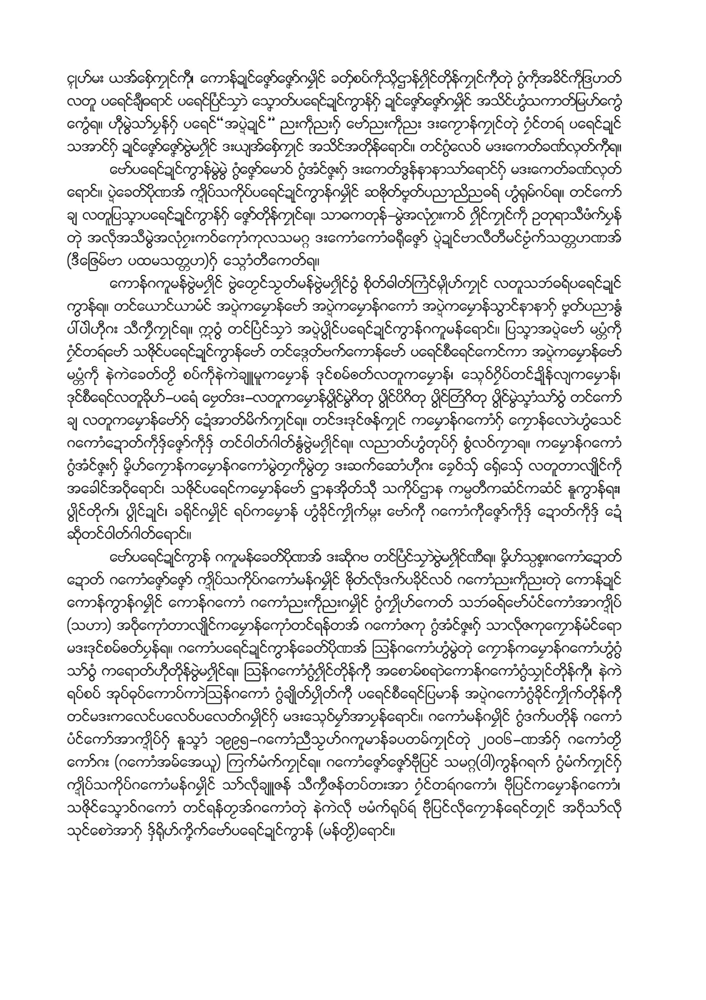

**OCR Result:**

```
ၚုဟ်မးယအ်စှ်ေကၠုၚ်ကီု၊ကောန်ဍုၚ်ဇၞော်ဇၞော်ဂမၠိုၚ်ခတှ်စပ်ကဵုသ္ၚိဌာန်ဂၠိုၚ်တိုန်ကၠုၚ်ကီုတုဲဂွံကဵုအခိၚ်ကဵုဒြဟတ်
လတူပရေၚ်ချဳဓရာၚ်ပရေၚ်ပြံၚ်သၠာဲသၞောတ်ပရေၚ်ဍုင်ကွာန်ဂှ်ဍုင်ဇၞော်ဇၞော်ဂမၠိုၚ်အအသိင်ဟွံကာတ်မြဟ်ကွေံ
ကွေံရ။ဟီုမွဲသာ်ပၠန်ဂှ်ပရေင််အပ္ဍဲဍုင်"ညးကဵုညးဂှ်ဗော်ညးကဵုညးဒးကၟောန်ကၠုၚ်တုဲဂၠံၚ်တရဴပရေၚ်ဍုၚ်
သဘာင်ဂှ်ဍုင်ဇၞော်ဇၞော်ဗွဲမဂၠိုၚ်ဒးယျအ်စှ်ေကၠုၚ်အအသိၚ်အတိုန်ရောၚ်။တၚ်ဂွံလေဝ်မဒးကေတ်ခဏ်လလ္ၚတ်ကီုရ။
ဗော်ပရေၚ်ဍုင်ကွာန်မွဲမွဲဂွံဇၞော်မောဝ်ဂွံအံၚ်ဇၞးဂှ်ဒးကေတ်ဒွန်နာနာသာ်ရောၚ်ဂှ်မဒးကေတ်ခဏ်လ္ၚတ်
ရောၚ်။ပ္ဍဲခေတ်ပိုဲဏအ်က္ဍိုပ်သကိုပ်ပရေင်ဍုင်ကွာန်ဂမၠိုင်ဆၜိုတ်ဗၞတ်ပညာညိညဓရ်ဟွံရုမ်ဂပ်ရ။တၚ်ကော်
ချလတူပြသၞာပရေၚ်ဍုၚ်ကွာန်ဂှ်ဇၞော်တိုန်ကၠုၚ်ရ။သာမကတုန်-မွဲလုံဂၠးကဝ်ဂၠိုၚ်ကၠုင်ကဵုဥတုရာသဳဖံက်ပၠန်
တုဲအလဵုအသဳမွဲအလုံဂၠးကဝ်ကေုာံကုလသမဂ္ဂဒးကောံကောံဓရီုဇၞော်ပ္ဍဲဍုၚ်ဗာလီတီမၚ်ဗၟံက်သတ္တဟဏအ်
(ဒီဇြေမ်ဗာပထမသတ္တဟ)ဂှ်သ္ဂောံတီကေတ်ရ၊။
ကောန်ဂကူမန်ဗွဲမဂၠိုၚ်ဗွဲတၟေၚ်သၟတ်မန်ဗွဲမဂၠိုၚ်ဝွံစိုတ်ဓါတ်ကြံၚ်မ္ၚိုဟ်ကၠုၚ်လတူသဘဴဓရ်ပရေၚ်ဍုၚ်
ကွာန်ရ။တၚ်ယောၚ်ယာမံၚ်အပ္ဍဲကမၠောန်ဗော်အပ္ဍဲကမၠောန်ဂကောံအအပ္ဍဲကမၠောန်သွာင်နာ?နဂှ်ဗၞတ်ပညာနွံ
ပါဲပဲဟီုဂးသီကၠဳကၠုၚ်ရ။ဣဝွံတၚ်ပြံၚ်သၠာဲပ္ဍဲပွိုၚ်ပရေၚ်ဍုၚ်ကွာန်ဂကူမန်ရောၚ်။ပြသၞာအပ္ဍဲဗော်မပ္တံကဵု
ဂၠံၚ်တရဴဗော်သဇိုင်ပရေၚ်ဍုင်ကွာန်ဗော်တၚ်ဒ္ဂေတ်ဗက်ကောန်ဗော်ပရေၚ်စဳရေင်ကေၚ်ကာအပ္ဍဲကမၠောန်ဗော်
မပ္တံကဵုနဲကဲခေတ်တၟိစပ်ကဵုနဲကဲချူမူကမၠောန်ဒုၚ်စမ်စတ်လတူကမၠောန်၊သ္ၚေဝ်ဂၠိပ်တၚ်ဍိုန်လျကမၠောန်
ဒုၚ်စဳရေၚ်လတူခိုဟ်-ပရေံဗၠေတ်ဒး-လတူကမၠောန်ပွိုၚ်မွဲဂိတုပွိုၚ်ပိဂိတုပွိုၚ်တြဴဂိတုပွို်မွဲသၞာံသာ်ဝွံတင်ကော်
ချလတူကမၠောန်ဗော်ဂှ်ဍေံအ်ာတ်မိက်ကၠုၚ်ရ။တၚ်ဒးဒုၚ်ဇန်ကၠုၚ်ကမၠောန်ဂကောံဂှ်ကၠောန်လောဲဟွံသေၚ်
ဂကောံဍောတ်ကဵုဒှ်ဇၞော်ကဵုဒှ်တၚ်ဝါတ်ဂါတ်နွံဗွဲမဂၠိုၚ်ရ။လညာတ်ဟွံတုပ်ဂှ်စွံလဝ်ကၠာရ။ကမၠောန်ဂကောံ
ဂွံအံၚ်ဇၞးဂှ်မၞိဟ်ကၠောန်ကမၠောန်ဂကောံမွဲတၠကဵုမွဲတၠဒးဆက်ဆောံဟီုဂးခၠေဝ်သှ်ရှ်ေသှ်ေလတူတာလျိုၚ်ကဵု
အခေါၚ်အဝ်ဵုရောၚ်၊သဇိုၚ်ပရေၚ်ကမၠောန်ဗော်ဋ္ဌြာနအိုတ်သီုသကိုပ်ဌာနကမ္မတီကဆံင်ကဆံင်နူကွာန်ရး
ပွိုင်တိုက်၊ပွိုင်ဍုင်၊ခရိုၚ်ဂမၠိုၚ်ရပ်ကမၠောန်ဟွံခိုၚ်ကၠိုက်မ္ဂးဗော်ကီုဂကောံကီုဇၞော်ကဵုဒှ်ဍောတ်ကဵုဒှ်ဍေံ
ဆဵုတၚ်ဝါတ်ဂါတ်ရောၚ်၊
ဗော်ပရေင်ဍုင်ကွာန်ဂကူမန်ခေတ်ပိုဲဏအ်ဒးဆဵုဂဗတၚ်ပြံၚ်သၠာဲဗွဲမဂၠိုၚ်ဏီရ။မၞိဟ်သ္ပစၞးဂကောံဍောတ်
ဍောတ်ဂကောံဇၞော်ဇၞော်က္ဍိုပ်သကိုပ်ဂကောံမန်ဂမၠိုင်ၜိုတ်လဵုဒက်ပခိုင်လဝ်ဂကောံညးကဵုညးတုဲကောန်ဍုၚ်
ကောန်ကွာန်ဂမၠိုၚ်ကောန်ဂကောံဂကောံညးကဵုညးဂမၠိုၚ်ဂွံကၠိုဟ်ကေတ်သဘဴဓရ်ဗော်ပံၚ်ကောံအက္ဍိုပ်
(သဟာ)အဝ်ဵုကေုာံတာလျိုၚ်ကမၠောန်ကေုာံတၚ်ရန်တအ်ဂကောံဇကုဂွံအံၚ်ဇၞးဂှ်သာလ်္ုဇကုကၠောန်မံၚ်ရော
မဒးဒုၚ်စမ်စတ်ပၠန်ရ။ဂကောံပရေၚ်ဍုၚ်ကွာန်ခေတ်ပိုဲဏအ်သြန်ဂကောံဟွံမွဲတုဲကၠောန်ကမၠောန်ဂကောံဟွံဂွံ
သာ်ဝွံကရောတ်ဟီုတိုန်ဗွဲမဂၠိုၚ်ရ။သြန်ဂကောံဂွံဂၠိုၚ်တိုန်ကီုစောမ်စရာဲကောန်ဂကောံဂွံသၠုၚ်တိုန်ကီု၊နဲကဲ
ရပ်စပ်အုပ်မုပ်ကောပ်ကာဲသြန်ဂကောံဂွံချိုတ်ပၠိုတ်ကီုပရေၚ်စဳရေၚ်ပြမာန်ပ္ဍဲဂကောံဂွံခိုၚ်ကၠိုက်တိုန်ကီု
တၚ်မဒးကလေင်ပလေဝ်ပလေတ်ဂမၠိုၚ်ဂှ်မဒးသ္ၚေဝ်မၠာ်အ်ပၠန်ရောၚ်။ဂကောံမန်ဂမၠိုၚ်ဂွံဒက်ပတိုန်ဂကောံ
ပံင်ကော်အာက္ဍိုပ်ဂှ်နူသၞာံ၁၉6၅-ဂကောံညဳသၟဟ်ဂကူမာန်ခပတမ်ကၠုင်တုဲ၂၀၀၆-ဏအ်ဂှ်ဂကောံတၟိ
ကော်ဂး(ဂကောံအမ်အေယူ)ကြက်မံက်ကၠုၚ်ရ။ဂကောံဇၞော်ဇၞော်ဗီုပြၚ်သမဂ္ဂ(ဝါဲ)ကွန်ဂရက်ဂွံမံက်ကၠုၚ်ဂှ်
က္ဍိုပ်သကိုပ်ဂကောံမန်ဂမၠိုၚ်သာ်လဵုချူဇန်သီကၠဳဇန်တပ်တးအာဂၠံၚ်တရဴဂကောံဗီုပြၚ်ကမၠောန်ဂကောံ
သဇိုၚ်သၞောဝ်ဂကောံတၚ်ရန်တၟအ်ဂကောံတုဲနဲကဲလဵုဗမံက်ရုပ်ရဴဗီုပြၚ်လဵုကၠောန်ရေၚ်တၠုၚ်အဝဵုသာ်လ်ဵု
သုၚ်စောဲအာဂှ်ဒှ်ရိုဟ်ကၞိက်ဗော်ပရေၚ်ဍုၚ်ကွာန်(မန်တၟိ)ရောၚ်။
```

----------------------------------------


In [6]:
if not pdf_dir.exists():
    print("No PDF folder")
else:
    pdfs = sorted(pdf_dir.glob("*.pdf"))
    print(f"Found {len(pdfs)} PDFs\n")

    for pdf_path in pdfs:
        display(Markdown(f"# {pdf_path.name}"))

        try:
            pages = convert_from_path(str(pdf_path))

            for i, page_img in enumerate(pages, start=1):
                display(Markdown(f"## Page {i}"))

                # Run OCR
                text = ocr.read_text(page_img)

                # Show page
                display_pil_image(page_img)

                # Show result
                display(Markdown("**OCR Result:**"))
                display(Markdown(f"```\n{text}\n```"))

                print("-" * 40)

        except Exception as e:
            print(f"Failed: {pdf_path.name} - {e}")